### Контекст
Этот набор данных представляет собой всестороннее моделирование торговых операций компании B.Laban (ب.لبن) в различных регионах, включая Египет, ОАЭ и Саудовскую Аравию. Он предназначен для специалистов по анализу данных, желающих попрактиковаться в очистке данных, разведочном анализе данных (EDA) и построении регрессионных моделей машинного обучения для прогнозирования общего объема продаж.

Данные намеренно представлены в "неупорядоченном" виде, чтобы имитировать реальные ситуации, и содержат пропущенные значения (NA), экстремальные выбросы и противоречивые записи.

In [2]:
import pandas as pd

from private import utils
from public import analyzer

data_frame : pd.DataFrame = utils.prepare_blaban_data()
analyzer.report(
    data_frame,
    [
        analyzer.dataset_stats_info,
        analyzer.duplicates_info,
        analyzer.missing_value_info,
        analyzer.not_numeric_columns_info,
        analyzer.anomalies_info
    ] 
)


total
	10000

head
	   Transaction_ID            Date_Time         Branch       Product_Name  \
	0          106253  2024-03-06 03:00:00    Alex-Stanly  Sweet Koshary Mix   
	1          104685  2024-02-18 19:00:00  Cairo-Zamalek      Super B.Laban   
	2          101732  2024-01-19 00:45:00    Alex-Stanly  Sweet Koshary Mix   
	3          104743  2024-02-19 09:30:00     Giza-Zayed       Om Ali Cream   
	4          104522  2024-02-17 02:15:00   Dubai-Marina  Rice Pudding Nuts   

	     Size  Unit_Price  Quantity  Discount_Rate Topping_Type  Customer_ID  ...  \
	0   Small      175.65         9           0.05          NaN        69698  ...   
	1   Large       67.31         9           0.00         Nuts        89206  ...   
	2  Medium      178.51         2           0.15      Nutella        71726  ...   
	3   Large       57.95        10           0.00          NaN        74303  ...   
	4   Large       89.67         4           0.00      Nutella        85273  ...   

	   Temperature_Celsius 

preprocessing took 0.173 seconds
training took 0.014 seconds
predict took 0.003 seconds
evaluate took 0.002 seconds
Коэффициенты линейной регрессии:
	[-7.32281273e-04 -1.01514821e-03 -8.51854887e-04 -3.56641482e-04
 -3.03445196e-04 -6.83250540e-02 -3.20692057e-04 -1.64659394e-04
  1.21764974e-04  6.44071344e-04  1.05592132e-03 -1.98821848e-04
 -7.02435805e-05 -3.17770876e-04  2.50695508e-04  3.06831328e-04
  3.13162984e-04 -7.18742367e-05  5.29947968e-04 -2.86688835e-04
  3.04786975e-04  3.25810426e-05 -6.24169869e-05 -6.48023940e-04
  9.96338657e-01]
Intercept:
	-2.763114414791402e-18
Среднеквадратичная ошибка:
	2.027861657839947
Коэффициент детерминации R^2:
	-1.027861657839947
report took 0.000 seconds


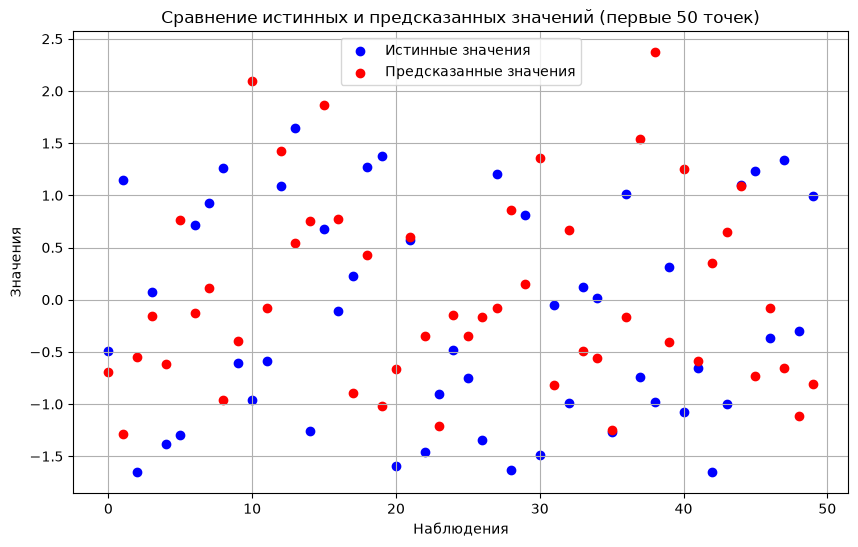

In [3]:
from public.model_for_linear_regresssion import LinearRegressionModel

model: LinearRegressionModel = (
        LinearRegressionModel(df=data_frame, target_column="Total_Sales")  # set datadrame
        .preprocessing(  # transmrm dataframe based on analizer info
            {
                "drop_columns": {"columns": ["Transaction_ID", "Date_Time"]},
                "fill_missing_data": {"strategy": "most_frequent"},
                "ordinal_encoding": {
                    "columns": [
                        "Branch",
                        "Product_Name",
                        "Size",
                        "Topping_Type",
                        "Customer_Gender",
                        "Membership_Status",
                        "Payment_Method",
                        "Order_Source",
                        "Category",
                        "Region",
                    ]
                },
                "standard_scaller": {},
            }
        )
        .training()  # trainig
        .predict()  # predicttion based on test data
        .evaluate()  # evaluate model presicion
)
model.report()
model.draw()